In [10]:
from typing import List
import random
from langgraph.graph import StateGraph, END, START
from typing import TypedDict, Dict

class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int

In [11]:
def greeting_node(state:AgentState) -> AgentState:
    """ Greeting node which says hi to person """
    state['name'] = f"Hi there, {state['name']}"
    state['counter'] = 0
    return state

def random_node(state: AgentState) -> AgentState:
    """Generates a random number from 0 to 10"""
    state['number'].append(random.randint(0,10)) 
    state['counter'] += 1

    return state

def should_continue(state: AgentState) -> AgentState:
    """Function to decide what to do next"""
    if(state['counter'] < 5):
        print('ENTERING LOOP', state['counter'])
        return "loop"
    else:
        return "exit"         

## greeting ->  random -> random -> random -> random ->random -> END

In [14]:
graph = StateGraph(AgentState)


graph.add_node("greeting_node", greeting_node)
graph.add_node("random_node", random_node)

graph.add_edge("greeting_node", "random_node")
graph.set_entry_point("greeting_node")

graph.add_conditional_edges(
    "random_node",
    should_continue,
    {
        "loop":"random_node",
        "exit": END
    }
)

app = graph.compile()

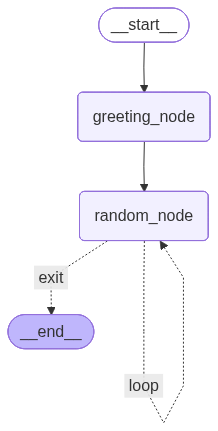

In [15]:
from IPython.core.display import Image
from IPython.core.display_functions import display
display(Image(app.get_graph().draw_mermaid_png()))

In [16]:
answer = app.invoke({"name":"Taiwo", "number":[], "counte": 100})

ENTERING LOOP 1
ENTERING LOOP 2
ENTERING LOOP 3
ENTERING LOOP 4
